# 深度学习初探：多分类任务实战

## 介绍

在上一章，我们利用PyTorch框架成功构建并训练了第一个多参数回归模型，实现了对“特调柠檬水顾客评分”的预测。通过上一章的实践，我们熟悉了PyTorch的核心组件——模型层、损失函数与优化器。

本章，我们将把任务从回归问题升级到多分类问题。这意味着我们需要从预测一个连续数值转变为预测多个离散的类别。为了实现这一转变，我们需要把模型的输出从单个值扩展为多个值，并使用新的损失函数来衡量模型的预测结果与真实标签之间的差异。同时，由于任务的复杂性增加，我们将把单层神经网络扩展为多层神经网络，以增强模型的表达能力，并引入Dataset和Dataloader来更高效地管理数据。

本章的目标是让读者快速掌握使用PyTorch处理分类任务的基本流程。将会以一个生动的“咖啡分类”场景贯穿始终，从零开始，一步步实现数据加载、模型构建、模型训练与评估预测的全过程。在这个过程中，你将亲手搭建一个能够区分不同种类咖啡的神经网络，并理解分类任务与回归任务在模型设计、损失函数选择上的核心差异。

现在，就让我们正式进入深度神经网络与多分类任务的世界，亲手搭建并训练第一个属于自己的分类模型吧！

## 最少必要知识

- 深度神经网络
- 分类任务和交叉熵损失
- Dataset和Dataloader
- 四大主流的优化器

## 任务背景

这是一个关于多分类任务的深度学习实战项目，使用咖啡数据集进行分类训练，目标是根据咖啡的配方成分（椰浆、咖啡、牛奶、糖）来识别咖啡的类型（生椰拿铁、双椰拿铁、烤椰拿铁）。

## 环境版本

打印环境的版本号，避免因为环境不同而导致程序不能复现。

In [21]:
from course_03.util import show_version

show_version()

+------+----------------------------------------------------------------------------------------+
| Info |                                   《动手学人工智能》                                   |
+------+----------------------------------------------------------------------------------------+
| 作者 |                                       吾辈亦有感                                       |
| 哔站 |                      https://space.bilibili.com/3461565265217538                       |
| 定位 |      基于'从零构建'的理念，用实战降低学习大模型的门槛，帮助程序员快速入门大模型。      |
| 愿景 | 若我的经验能让你的AI学习之路走的更容易一点，让你的生活变得更美好，我将倍感荣幸！祝好😄 |
+------+----------------------------------------------------------------------------------------+

环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 准备数据

### 观察数据


In [22]:
import pandas as pd

# 读取训练集数据
train_data_frame = pd.read_csv('./dataset/coffee_train.csv')

# 随机显示5行数据
train_data_frame.sample(5)

,椰浆,咖啡,牛奶,糖,种类
90,6.5000,3.2000,5.1000,2.0000,烤椰拿铁
104,6.7000,3.3000,5.7000,2.1000,烤椰拿铁
91,6.4000,2.7000,5.3000,1.9000,烤椰拿铁
71,5.5000,2.4000,3.7000,1.0000,双椰拿铁
15,5.7000,4.4000,1.5000,0.4000,生椰拿铁


### PyTorch 数据管理
PyTorch中的 `Dataset` 和 `DataLoader` 类是数据加载和处理的核心组件，它们极大地简化了数据准备和批量加载的过程，使得训练循环更加清晰和高效。

**Dataset类的作用：**
1. 抽象数据表示：Dataset类提供了一个表示数据集的抽象接口，允许用户自定义如何加载和访问数据。
2. 数据预处理：可以在Dataset类中实现数据的预处理操作，如图像的变换、文本的分词等。
3. 统一数据访问：通过实现__getitem__和__len__方法，使得数据集可以像列表一样被索引，并且可以获取数据集的大小。

**DataLoader类的作用：**
1. 批量加载：自动将数据集中的数据分成小批量，便于模型训练。
2. 数据打乱：在每个训练周期（epoch）开始时，可以随机打乱数据，以减少模型对数据顺序的依赖，提高泛化能力。
3. 并行加载：利用多进程并行加载数据，加速数据准备过程，减少GPU等待数据的时间。
4. 灵活的数据组合：通过collate_fn参数，可以自定义如何将多个样本组合成一个批量，例如对序列数据进行填充。

PyTorch 中数据加载的整体思路如图所示：【图示】

**使用Dataset和DataLoader的好处：**
1. 模块化：将数据加载和预处理与模型训练代码分离，使得代码结构更清晰，易于维护和修改。
2. 效率：通过并行加载和数据预取，可以充分利用计算资源，减少训练时间。
3. 灵活性：可以轻松地处理不同类型的数据和不同的数据存储格式。
4. 可重复性：通过设置随机种子，可以确保每次训练时数据打乱的方式相同，便于实验复现。

### 自定义数据集

自定义咖啡分类 `CoffeeDataset` 类，需要继承 `torch.utils.data.Dataset`，并实现`__init__`、`__len__`和`__getitem__`方法。
- `__init__` 方法：初始化数据集，通常包含样本列表、标签映射等参数。
- `__len__` 方法：返回数据集的长度，即样本数量。
- `__getitem__` 方法：根据索引获取指定样本的数据，通常会将数据的转换过程放在这里。

在此次的任务中我们需要将csv中的每一行数据转化为一条训练样本。转化示例如下：

【图示】

其中 `input_ids` 表示输入特征，`target_ids` 表示类别对应的ID。

#### 自定义咖啡分类数据集

除了实现`__init__`、`__len__`和`__getitem__`方法，我们还需要添加从CSV文件加载数据的类方法 `load_from_csv`，方便直接从数据文件中直接创建数据集对象。

In [23]:
import torch
from torch.utils.data import Dataset


class CoffeeDataset(Dataset):
    """
    自定义咖啡数据集类，继承自PyTorch的Dataset基类
    用于加载和处理咖啡分类数据
    """

    def __init__(self, samples, label_to_id):
        """
        初始化数据集
        
        参数:
        - samples: 包含特征和标签的样本列表，每个元素是(features, label)的元组
        - label_to_id: 标签到ID的映射字典，如果为None则自动创建
        """
        self.samples = samples

        # 使用提供的标签映射
        self.label_to_id = label_to_id
        # 创建反向映射(ID到标签)，用于后续将预测结果转换回标签名称
        self.id_to_label = {idx: label for label, idx in self.label_to_id.items()}

    def __len__(self):
        """
        返回数据集的大小(样本总数)
        
        返回:
        - 数据集中的样本数量
        """
        return len(self.samples)

    def __getitem__(self, index):
        """
        获取指定索引的样本数据
        
        参数:
        - index: 样本索引
        
        返回:
        - 包含输入特征和目标标签ID的字典
        """
        # 1️⃣ 根据索引获取样本的特征和标签
        features, label = self.samples[index]

        # 2️⃣ 将标签转换为对应的ID
        label_id = self.label_to_id[label]

        # 3️⃣ 返回包含输入特征和目标标签ID的字典
        return {
            "input_features": features,  # 输入特征数据
            "target_ids": label_id  # 目标标签ID
        }

    @classmethod
    def load_from_csv(cls, file_path, label_to_id):
        """
        从CSV文件加载数据的类方法
        
        参数:
        - file_path: CSV文件路径
        
        返回:
        - CoffeeDataset实例
        """
        # 使用pandas读取CSV文件并删除包含缺失值的行
        data = pd.read_csv(file_path).dropna()

        # 存储处理后的样本
        samples = []

        # 遍历数据中的每一行
        for index in range(len(data)):
            # 1️⃣ 获取当前行数据
            row = data.iloc[index]

            # 2️⃣ 提取特征数据(除最后一列外的所有列)，并转换为float32类型
            features = row.iloc[:-1].values.astype("float32")

            # 3️⃣ 提取标签(最后一列)
            label = row.iloc[-1]

            # 4️⃣ 将特征和标签作为一个元组添加到样本列表中
            samples.append((features, label))

        # 创建并返回CoffeeDataset实例
        return cls(samples, label_to_id)

#### 加载数据集实例

使用训练数据文件`coffee_train.csv` 和评估数据文件 `coffee_val.csv` 来创建对应的数据集对象。

In [24]:
from pprint import pprint

# 使用 CoffeeDataset 类的 load_from_csv 方法加载咖啡数据集
label_to_id = {"生椰拿铁": 0, "双椰拿铁": 1, "烤椰拿铁": 2}
train_dataset = CoffeeDataset.load_from_csv("./dataset/coffee_train.csv", label_to_id)
val_dataset = CoffeeDataset.load_from_csv("./dataset/coffee_val.csv", label_to_id)

# 使用 pprint 函数打印数据集中的第一个样本，展示其结构和内容
# 这有助于查看数据的格式，包括输入特征(input_ids)和目标标签(target_ids)
print(f"数据集样例：{train_dataset[0]}\n")

# 打印训练集和评估集的大小
print(f"训练集大小: {len(train_dataset)}")
print(f"评估集大小: {len(val_dataset)}")

数据集样例：{'input_features': array([5.1, 3.5, 1.4, 0.2], dtype=float32), 'target_ids': 0}

训练集大小: 118
评估集大小: 30


### 数据加载器

DataLoader是PyTorch中用于加载数据的一个重要工具，它提供了一个可迭代的对象，可以方便地访问Dataset中的数据，并支持自动批处理、打乱数据、多进程加载等。
有以下主要参数：
- dataset: 一个Dataset对象，即要加载的数据集。
- batch_size: 每个批次的大小，默认为1。
- shuffle: 是否在每个epoch开始时打乱数据，默认为False。通常训练集设置为True，验证集/测试集为False。
- num_workers: 使用多少个子进程来加载数据，默认为0，表示在主进程中加载。
- collate_fn: 如何将多个样本数据拼接成一个批次，默认为torch默认的拼接方式。
- drop_last: 当数据集大小不能被batch_size整除时，是否丢弃最后一个不完整的批次。

下面基于自定义的咖啡分类数据集创建数据加载器。这里创建一个批次大小为5的训练数据加载器，并打印一个批次的数据。

#### 创建数据加载器

创建数据加载器的时候需要设置数据集、批次大小、是否打乱数据等参数，训练数据加载器通常会打乱数据，而评估数据加载器则通常不需要打乱数据。

In [25]:
from torch.utils.data import DataLoader

# 设置每个批次的数据量
batch_size = 5

# 创建训练数据的数据加载器，打乱数据
# DataLoader会自动处理数据的批量加载和随机打乱（shuffle=True）
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 创建评估数据的数据加载器，无需打乱数据
# 评估时通常不需要打乱数据（shuffle=False），以便于结果的复现和分析
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#### 使用数据加载器

当我们实例化一个 DataLoader 后，它返回的是一个可迭代对象。对其实例进行迭代时，会调用其__iter__方法，该方法返回一个迭代器。这个迭代器在每次迭代时返回一个批次（batch）的数据。

在这个迭代器内部会维护一个索引，每次迭代时，它会根据采样器（Sampler）提供的索引来从数据集中获取数据，然后使用将单个样本组合成一个batch。所以我们可以通过下面for循环的迭代方式每次获取一个批次的数据，直到数据遍历一遍为止。

In [26]:
# 使用 Dataloader 打印一个批次的数据
print("使用 Dataloader 打印一个批次的数据：")

input_features = None
target_ids = None

# 遍历训练数据加载器，获取一个批次的数据
for batch in train_dataloader:
    # 从批次数据中提取输入特征(input_features)和目标标签(target_ids)
    input_features = batch["input_features"]
    target_ids = batch["target_ids"]

    # 使用pprint美化打印批次数据，sort_dicts=False保持字段顺序
    pprint(batch, sort_dicts=False)

    # 只打印第一个批次后就跳出循环
    break

使用 Dataloader 打印一个批次的数据：
{'input_features': tensor([[6.2000, 2.8000, 4.8000, 1.8000],
        [6.3000, 3.4000, 5.6000, 2.4000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [6.9000, 3.2000, 5.7000, 2.3000],
        [5.2000, 3.5000, 1.5000, 0.2000]]),
 'target_ids': tensor([2, 2, 0, 2, 0])}


从执行结果中和我们的预期一样，每次迭代都会返回一个批次为 5 的数据，其中包含输入特征`input_features`和目标标签`target_ids`。迭代时 DataLoader 会自动地根据样本中的key进行堆叠，所以`input_features`和`target_ids`都被转换成了列表的形式，它们的数据形状为：
- `input_features`：(5, 4)，即每个批次有5个数据样本，每个样本有4个输入特征
- `target_ids`：(5,)，即每个批次有5个数据样本，每个样本有1个目标标签

:::{admonition} 批次：用部分对整体的近似估计
:class: note
这里我们引入了批次（batch）的概念，在《神经网络启蒙》中训练顾客评分预测模型时，每次训练都会使用全部的数据，虽然使用全量的数据其loss更能精准的表示模型的性能，但是训练的过程会很慢。因此，在训练过程中，通常会采用小批量（mini-batch）的数据去近似估计整个训练集，即每次只使用一部分数据进行训练，从而平衡训练效率和模型性能。

正式因为这种近似估计的理念，所以通常会将训练数据集进行随机打乱，每个训练轮次中批次的数据都不同，可以让数据集更接近真实分布，从而提高模型的泛化性能。
:::

## 构建模型

本次任务我们需要创建一个用于咖啡分类的模型，学习四种配料与咖啡品类之间的关系。这是一个拥有多个神经网络层和多个输出的模型，其模型结构如下：

**【配图】**

### 定义模型

定义一个继承自 `nn.Module` 的 `CoffeeClassifier` 类，这是PyTorch中定义神经网络模型的标准方式。

重写模型的 `__init__` 和 `forward` 方法，分别完成模型的初始化和前向计算。
- `__init__` 方法：定义模型的参数和层结构，创建一个输入层和一个输出层，不同的层之间使用 `ReLU` 激活函数进行非线性映射。
- `forward` 方法：定义数据在网络中的流动方式，先通过输入层进行数据输入，然后通过隐藏层进行非线性映射，最后通过输出层进行分类预测。

:::{admonition} 激活函数：从线性到非线性的飞跃
:class: note
激活函数是施加在人工神经网络每个神经元输出上的数学函数。它的核心使命是引入非线性。这是神经网络能够学习并逼近任意复杂函数关系的基石。

一个没有激活函数的神经网络，无论有多少层，其整体输出都只是输入数据的线性组合，本质上等价于一个单层的神经网络，能力极其有限。激活函数打破了这种线性束缚，使得神经网络能够拟合曲线、形成复杂的决策边界，从而处理图像识别、自然语言处理等高度非线性的现实问题。
:::

In [27]:
from torch import nn


class CoffeeClassifier(nn.Module):
    """
    咖啡分类模型，继承自PyTorch的nn.Module基类
    这是一个简单的两层全连接神经网络，用于咖啡种类分类任务
    """

    def __init__(self, input_size, hidden_size, output_size):
        """
        初始化模型结构
        
        参数:
        - input_size: 输入特征维度（本项目中为4，即椰浆、咖啡、牛奶、糖的含量）
        - hidden_size: 隐藏层神经元数量
        - output_size: 输出类别数量（本项目中为3，即生椰拿铁、双椰拿铁、烤椰拿铁）
        """
        # 调用父类初始化方法
        super(CoffeeClassifier, self).__init__()

        # 输入层：将输入特征映射到隐藏层
        self.input_layer = nn.Linear(input_size, hidden_size)

        # 激活函数：引入非线性因素，增强模型表达能力
        self.relu = nn.ReLU()

        # 输出层：将隐藏层映射到输出类别
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, input_features):
        """
        前向传播函数，定义数据在网络中的流动过程
        
        参数:
        - input_features: 输入数据，形状为(batch_size, input_size)
        
        返回:
        - out: 模型输出，形状为(batch_size, output_size)
        """
        # 输入通过输入层，数据形状变化：(batch_size, hidden_size) → (batch_size, hidden_size)
        out = self.input_layer(input_features)

        # 经过ReLU激活函数
        out = self.relu(out)

        # 通过输出层得到最终输出，数据形状变化：(batch_size, hidden_size) → (batch_size, output_size)
        out = self.output_layer(out)

        # 返回输出结果
        return out

### 创建模型实例

创建咖啡分类模型实例，并打印模型信息：
 - 输入特征维度为4（椰浆、咖啡、牛奶、糖）
 - 隐藏层维度为10
 - 输出类别数为3（生椰咖啡、双椰咖啡、烤椰咖啡）

In [28]:
"""
创建咖啡分类模型实例：
 - 输入特征维度为4（椰浆、咖啡、牛奶、糖）
 - 隐藏层维度为10
 - 输出类别数为3（生椰咖啡、双椰咖啡、烤椰咖啡）
"""
model = CoffeeClassifier(input_size=4, hidden_size=10, output_size=3)

# 打印模型结构
print(model)

CoffeeClassifier(
  (input_layer): Linear(in_features=4, out_features=10, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=10, out_features=3, bias=True)
)


从打印的模型信息中可以看到，模型由输入层、激活函数和输出层组成，其中：
- 输入层 `input_layer`：将输入特征映射到隐藏层，输入特征维度为4，隐藏特征维度为10
- 激活函数 `relu`：使用 ReLU 激活函数，引入非线性因素，增强模型表达能力
- 输出层 `output_layer`：将隐藏特征映射到输出类别，隐藏特征维度为10，输出类别数为3

### 查看模型结构

使用 `torchinfo` 库查看模型的结构，包括输入大小、输出大小、参数数量和是否可训练。

In [29]:
from torchinfo import summary

# input_data: 输入数据的形状，用于推断模型的输入输出大小
# col_names: 指定显示的列名，包括输入大小、输出大小、参数数量和是否可训练
print("Model Summary:")
print(summary(model, input_data=input_features,
              col_names=["input_size", "output_size", "num_params"]))

Model Summary:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CoffeeClassifier                         [5, 4]                    [5, 3]                    --
├─Linear: 1-1                            [5, 4]                    [5, 10]                   50
├─ReLU: 1-2                              [5, 10]                   [5, 10]                   --
├─Linear: 1-3                            [5, 10]                   [5, 3]                    33
Total params: 83
Trainable params: 83
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


## 训练前评估

训练前评估为模型性能建立了初始基准，使得后续的训练进度能够被量化追踪。通过对比训练前后的评估结果，开发者可以清晰看到模型的改进幅度，判断训练是否朝着正确的方向发展。

### 定义评估函数

创建一个评估函数`evaluate`，用于评估模型在测试数据集上的准确率。评估时会遍历测试数据加载器中的每个批次，计算模型的预测结果，并统计正确预测的样本数和总样本数，最后计算模型在整个测试数据集上的准确率。

评估每个批次具体步骤如下：
1. 从批次数据中获取输入特征和目标标签
2. 模型根据输入特征进行前向计算，得到针对每个样本在每个类型上的预测得分
3. 使用 `argmax` 获取每个样本预测概率最高的类别作为预测结果，即预测结果为预测概率最高的类别的索引
4. 比对预测结果和目标标签，统计当前批次中预测正确的样本数，并累加到总正确样本数中
5. 统计并累加当前批次的总样本数

:::{admonition} 注意
:class: note
1. 评估时，使用 `torch.no_grad()` 关闭梯度计算，可以在推理过程中不存储中间结果，减少显存占用
2. 评估时，使用 `to(device)` 将模型和数据移动到指定设备上，只有模型和数据在同一设备上时，才能进行计算
:::

In [30]:
from util import print_red


def evaluate(model, dataloader, device="cpu"):
    """
    评估模型在测试数据集上的准确率
    
    参数:
    - model: 训练好的模型
    - dataloader: 待测试数据集的数据加载器
    - device: 运行设备，默认为CPU
    
    返回:
    - accuracy: 准确率
    - total_correct: 正确预测的样本数
    - total_samples: 总样本数
    """
    # 将模型设置为评估模式，关闭如dropout等训练时特有的操作
    model.eval()
    # 将模型移动到指定设备上，只有模型和数据在同一设备上时，才能进行计算
    model.to(device)

    # 初始化正确预测的样本数和总样本数
    total_correct = 0
    total_samples = 0

    # 关闭梯度计算，因为在评估阶段不需要计算梯度，降低显存开销
    with torch.no_grad():
        # 遍历测试数据加载器中的每个批次
        for batch_data in dataloader:
            # 1️⃣ 从批次数据中获取输入特征和目标标签
            input_features, target_ids = batch_data["input_features"], batch_data["target_ids"]
            # 将输入数据和目标标签移动到指定设备上
            input_features, target_ids = input_features.to(device), target_ids.to(device)

            # 2️⃣ 模型前向传播，得到输出（未经过argmax处理）
            output_logits = model(input_features)

            # 3️⃣ 获取每个样本预测概率最高的类别作为预测结果
            predicted_ids = torch.argmax(output_logits, dim=1)

            # 4️⃣ 统计当前批次中预测正确的样本数
            total_correct += (predicted_ids == target_ids).sum().item()
            
            # 5️⃣ 累加当前批次的样本总数
            total_samples += target_ids.size(0)

    # 计算准确率
    accuracy = total_correct / total_samples
    # 打印准确率信息
    print_red(f"Accuracy: {accuracy:.4f} ({total_correct}/{total_samples})")
    # 返回准确率、正确预测的样本数和总样本数
    return accuracy, total_correct, total_samples

### 评估模型训练前准确率

In [31]:
from util import print_table

# 评估模型在评估集上的准确率
accuracy, total_correct, total_samples = evaluate(model, val_dataloader, device="cpu")

# 打印评估结果表格
print_table("🎯 训练前预测准确率", ["总样本数", "正确样本数", "准确率"],
            [[total_samples, total_correct, f"{accuracy * 100:.2f}%"]])

Accuracy: 0.3333 (10/30)

🎯 训练前预测准确率：
+----------+------------+--------+
| 总样本数 | 正确样本数 | 准确率 |
+----------+------------+--------+
|    30    |     10     | 33.33% |
+----------+------------+--------+


## 训练模型

训练深度神经网络的典型训练循环：

**【图示】**

### 定义训练循环

1. 创建一个训练函数`train_one_batch`，用于对一个批次的数据进行训练。
2. 创建一个训练函数`train_one_epoch`，用于对一个轮次的数据进行训练。
3. 创建一个训练函数`train_model`，用于对多个轮次的数据进行训练。

#### 训练一个批次

定义 `train_one_batch` 函数，用于对一个批次的数据进行训练。
1. 前向传播：将输入数据传入模型，得到预测类别的得分（未经过argmax处理）
2. 计算损失：使用损失函数计算预测类别与真实类别之间的误差
3. 清空梯度：在反向传播前清空优化器中的梯度缓存，以避免梯度累积
4. 反向传播：计算损失相对于模型参数的梯度
5. 参数更新：使用优化器根据计算出的梯度更新模型参数
6. 返回损失：返回当前批次的损失值，记录训练过程中性能的变化


In [32]:
def train_one_batch(model, optimizer, loss_fn, input_features, target_ids):
    model.train()  # 将模型设置为训练模式

    # 1️⃣ 前向传播：将输入数据传入模型，得到预测输出
    output_logits = model(input_features)

    # 2️⃣ 计算损失：使用损失函数计算预测值与真实值之间的误差
    loss = loss_fn(output_logits, target_ids)

    # 3️⃣ 清零梯度：在反向传播前清空优化器中的梯度缓存
    optimizer.zero_grad()

    # 4️⃣ 反向传播：计算损失相对于模型参数的梯度
    loss.backward()

    # 5️⃣ 更新参数：根据计算出的梯度更新模型参数
    optimizer.step()

    # 6️⃣ 返回当前批次的损失值
    return loss

#### 训练一个轮次

定义 `train_one_epoch` 函数，遍历数据加载器中的每一个批次，进行一个轮次的训练。

In [33]:
def train_one_epoch(model, optimizer, loss_fn, train_dataloader, device="cpu", log_interval=50):
    epoch_loss = 0  # 累计损失
    batch_ids = 0  # 批次计数器

    # 遍历训练数据加载器中的每一个批次
    for batch_data in train_dataloader:
        # 1️⃣ 从批次中获取输入和标签，并移动到指定设备
        # input_ids: 输入特征数据
        # target_ids: 真实标签数据
        input_features, target_ids = batch_data["input_features"], batch_data["target_ids"]
        input_features, target_ids = input_features.to(device), target_ids.to(device)

        # 2️⃣ 调用train_one_batch函数训练一个批次并返回损失
        batch_loss = train_one_batch(model, optimizer, loss_fn, input_features, target_ids)

        batch_ids += 1  # 增加批次计数器
        epoch_loss += batch_loss.item()  # 累加当前批次的损失值

        # 3️⃣ 按照指定间隔打印损失值，用于监控训练过程
        if batch_ids % log_interval == 0:
            print(f"Batch {batch_ids}, loss -> {batch_loss.item()}")

    # 计算并返回该epoch的平均损失
    return epoch_loss / len(train_dataloader)

#### 训练多个轮次

定义 `train_model` 函数，对模型进行多轮训练。该函数将：

- **循环执行指定数量的训练轮次（epoch）**
- **记录每个epoch的平均损失值**
- **按设定间隔进行模型评估**
- **监控模型性能变化趋势**

在训练过程中，系统会定期对模型在验证集上的表现进行评估，便于实时观察模型的学习效果和性能提升情况。

In [34]:
def train_model(num_epochs, model, optimizer, loss_fn, train_dataloader, val_dataloader, device="cpu",
                log_interval=50, val_interval=3):
    """
    训练模型

    Returns: 包含训练损失和评估准确率的列表。
    """

    train_losses = []  # 存储每个 epoch 的训练损失
    val_accuracies = []  # 存储每个评估点的准确率

    # 循环执行指定数量的训练轮次(epoch)
    for epoch in range(num_epochs):
        # 打印当前轮次信息
        print(">" * 30, f"Epoch {epoch + 1} / {num_epochs}", "<" * 30)

        # 1️⃣ 调用 train_one_epoch 函数训练一个完整的 epoch，返回该 epoch 的平均损失值
        epoch_loss = train_one_epoch(model, optimizer, loss_fn, train_dataloader, device=device, log_interval=log_interval)

        # 2️⃣ 将当前 epoch 的损失信息保存到 train_losses 列表中
        train_losses.append({
            "epoch": epoch + 1,  # epoch编号
            "loss": epoch_loss  # 平均损失值
        })

        # 3️⃣ 定期评估模型性能：每隔 eval_interval 轮或者在最后一轮进行评估
        if (epoch + 1) % val_interval == 0 or epoch == num_epochs - 1:
            # 调用 evaluate 函数评估模型在验证集上的准确率
            accuracy, total_correct, total_samples = evaluate(model, val_dataloader, device="cpu")

            # 将评估结果保存到 eval_accuracies 列表中
            val_accuracies.append({
                "epoch": epoch + 1,  # epoch编号
                "总样本数": total_samples,  # 验证集总样本数
                "正确样本数": total_correct,  # 预测正确的样本数
                "准确率": accuracy  # 准确率
            })

    # 返回训练过程中的损失记录和评估结果
    return train_losses, val_accuracies

### 启动训练循环

定义好了训练方法后，可以开始训练模型了。训练模型需要以下步骤：
- 加载数据集：加载训练集和验证集
- 创建数据加载器：设置批处理大小为20，创建训练数据加载器和评估数据加载器
- 创建模型实例：`input_size` 为输入特征向量的维度，`num_classes` 为类别数量
- 初始化模型训练组件：损失函数和优化器
    - 损失函数：因为此任务为分类任务，使用交叉熵损失函数（CrossEntropyLoss）
    - 优化器：使用 Adam 优化器优化模型参数，学习率为0.01
- 执行训练循环：调用 `train_model` 函数进行30轮训练，每3轮进行一次评估，每20个批次记录一次训练损失。

In [35]:
# 设置 GPU 设备类型
# 检查是否有可用的CUDA设备(GPU)
if torch.cuda.is_available():
    device = "cuda"
# 如果没有CUDA设备，检查是否有可用的MPS设备(Mac上的GPU加速)
elif torch.backends.mps.is_available():
    device = "mps"
# 如果都没有，则使用CPU
else:
    device = "cpu"

# 打印当前使用的设备类型
print(f"Using device: {device}")

# 1️⃣ 加载数据集
label_to_id = {"生椰拿铁": 0, "双椰拿铁": 1, "烤椰拿铁": 2}
train_dataset = CoffeeDataset.load_from_csv("./dataset/coffee_train.csv", label_to_id)
val_dataset = CoffeeDataset.load_from_csv("./dataset/coffee_val.csv", label_to_id)

# 2️⃣ 创建数据加载器 
# 设置批处理大小
batch_size = 20
# 创建训练数据加载器，shuffle=True表示每个epoch打乱数据顺序
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# 创建评估数据加载器，shuffle=False表示不打乱数据顺序
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 3️⃣ 创建新的咖啡分类模型实例
model = CoffeeClassifier(input_size=4, hidden_size=10, output_size=3)

# 4️⃣ 设置训练轮数
num_epochs = 30

# 5️⃣ 开始训练模型
# model: 要训练的模型
# optimizer: 优化器，使用Adam优化器，学习率为0.01
# loss_fn: 损失函数，使用交叉熵损失函数
# train_dataloader: 训练数据加载器
# val_dataloader: 评估数据加载器
# device: 设备类型，这里设置为"cpu"
train_losses, eval_accuracies = train_model(num_epochs, model=model, optimizer=torch.optim.Adam(model.parameters(), lr=0.01),
                                      loss_fn=nn.CrossEntropyLoss(),
                                      train_dataloader=train_dataloader, val_dataloader=val_dataloader, device="cpu")

Using device: mps
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 1 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 2 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 3 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Accuracy: 0.3333 (10/30)
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 4 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 5 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 6 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Accuracy: 0.6667 (20/30)
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 7 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 8 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 9 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Accuracy: 0.8333 (25/30)
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 10 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 11 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Epoch 12 / 30 <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
Accu

#### 训练过程可视化

绘制训练过程中损失值的变化曲线，更直观地观察损失值在训练过程中的变化趋势。

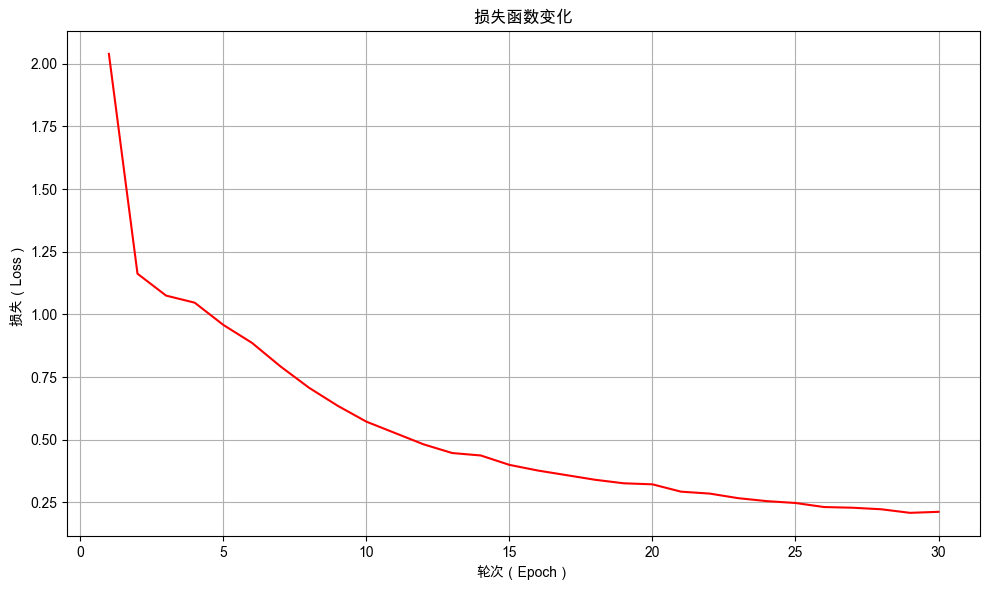

In [36]:
from util import plot_training_loss

plot_training_loss(train_losses)

从训练日志中可以看出随着训练的进行，损失值不断下降，表示模型预测准确性不断提高。

#### 查看模型评估记录

查看训练过程中的评估结果，更直观地观察模型在验证集上的表现。

In [37]:
from util import show_table

print("Eval Accuracies:")
show_table(eval_accuracies)

Eval Accuracies:


,epoch,总样本数,正确样本数,准确率
0,3,30,10,0.3333
1,6,30,20,0.6667
2,9,30,25,0.8333
3,12,30,30,1.0000
4,15,30,30,1.0000
5,18,30,30,1.0000
6,21,30,30,1.0000
7,24,30,30,1.0000
8,27,30,30,1.0000
9,30,30,30,1.0000


## 训练后评估

In [38]:
from util import print_table

accuracy, total_correct, total_samples = evaluate(model, val_dataloader, device="cpu")

print_table("🎯 训练前预测准确率", ["总样本数", "正确样本数", "准确率"],
            [[total_samples, total_correct, f"{accuracy * 100:.2f}%"]])

Accuracy: 1.0000 (30/30)

🎯 训练前预测准确率：
+----------+------------+---------+
| 总样本数 | 正确样本数 |  准确率 |
+----------+------------+---------+
|    30    |     30     | 100.00% |
+----------+------------+---------+


从评估结果中可以看出，训练前的模型的准确率是33.3%，训练后的准确率是100%，说明模型训练非常有效果。

## 使用模型进预测

### 定义预测单个样本的函数

In [39]:
def predict_sample(model, sample_features, id_to_label):
    """
    使用训练好的模型对单个样本进行预测
    
    参数:
    - model: 训练好的模型
    - sample_features: 样本特征，如 [椰浆, 咖啡, 牛奶, 糖]
    - id_to_label: 标签映射
    
    返回:
    - predicted_label: 预测的类别名称
    - predicted_probabilities: 各类别的预测概率
    """
    # 将模型设置为评估模式，关闭dropout等训练时特有的操作
    model.eval()

    # 转换输入特征为tensor
    input_features_tensor = torch.tensor(sample_features, dtype=torch.float32)

    # 添加批次维度，因为模型期望输入是批量数据
    # unsqueeze(0)在第0维添加一个维度，例如 shape [4] -> [1, 4]
    input_features_tensor = input_features_tensor.unsqueeze(0)

    # 模型预测
    with torch.no_grad():  # 关闭梯度计算，节省内存并提高推理速度
        # 前向传播得到模型输出
        output_logits = model(input_features_tensor)
        # 对输出应用softmax函数，将logits转换为概率分布
        probabilities = torch.softmax(output_logits, dim=1)
        # 获取概率最高的类别作为预测类别的ID
        predicted_id = torch.argmax(output_logits, dim=1)

    # 获取预测类别名称：通过id_to_label字典将类别ID转换为类别名称
    predicted_label = id_to_label[predicted_id.item()]

    # 返回预测标签和概率分布列表
    # squeeze()移除多余的维度，tolist()将tensor转换为Python列表
    return predicted_label, probabilities.squeeze().tolist()

### 使用训练好的模型进行预测

模型训练完成后，可以使用训练好的模型对新的数据进行预测，查看模型的泛化能力。

创建3个新样本，每个样本包含[椰浆, 咖啡, 牛奶, 糖]四个特征以及对应的类别，使用模型进行预测，查看模型的预测结果是否正确。

In [40]:
from util import print_classification_results

# 初始化各类别的标签到ID的映射关系（需要和训练模型时一致）
label_to_id = {"生椰拿铁": 0, "双椰拿铁": 1, "烤椰拿铁": 2}
id_to_label = {v: k for k, v in label_to_id.items()}


# 1️⃣ 假设我们有几个新的咖啡样本，每个样本包含[椰浆, 咖啡, 牛奶, 糖]四个特征
sample_features = [[4.4, 2.9, 1.4, 0.2], [6, 2.9, 4.5, 1.5], [6.9, 3.2, 5.7, 2.3]]
# 定义这些样本对应的真实标签
true_labels = ["生椰拿铁", "双椰拿铁", "烤椰拿铁"]
# 将真实标签转换为对应的ID
true_label_ids = [label_to_id[label] for label in true_labels]

# 2️⃣ 使用训练好的模型对每个样本进行预测
predictions = []  # 存储预测的标签名称
probabilities = []  # 存储各类别的预测概率
for i, sample_feature in enumerate(sample_features):
    # 对单个样本进行预测，返回预测标签和各类别概率
    predicted_label, probabilities_label = predict_sample(model, sample_feature, id_to_label)
    predictions.append(predicted_label)  # 添加预测标签
    probabilities.append(probabilities_label)  # 添加概率分布

# 3️⃣ 将预测的标签名称转换为对应的ID
predicted_label_ids = [label_to_id[prediction] for prediction in predictions]

# 4️⃣ 输出最终的分类预测结果，包括准确率统计和详细对比
print_classification_results(sample_features, true_label_ids, predicted_label_ids, probabilities, id_to_label)


🎯 分类预测结果 (准确率: 3/3 = 100.00%)：
+----------------------+----------+----------+----------+------+
|         输入         | 真实标签 | 预测标签 | 最高概率 | 标记 |
+----------------------+----------+----------+----------+------+
| [4.4, 2.9, 1.4, 0.2] | 生椰拿铁 | 生椰拿铁 |  0.9507  |  ☑   |
|  [6, 2.9, 4.5, 1.5]  | 双椰拿铁 | 双椰拿铁 |  0.6483  |  ☑   |
| [6.9, 3.2, 5.7, 2.3] | 烤椰拿铁 | 烤椰拿铁 |  0.8999  |  ☑   |
+----------------------+----------+----------+----------+------+


从结果中我们可以看到，模型在所有测试样本上都做出了正确预测。但是，对每一个样本模型的置信度仍然存在差异：
- 样本1 (生椰拿铁): 预测概率0.9507，置信度很高
- 样本2 (双椰拿铁): 预测概率0.6483，置信度中等
- 样本3 (烤椰拿铁): 预测概率0.8999，置信度较高

样本2的预测概率相对较低(0.6483)，说明模型对这个样本的分类相对不够确定，表示模型对预测的结果不够自信。如果置信度低于阈值（0.8），我们可以认为这个样本偏离了我们的训练数据集，也就是说这杯咖啡未通过模型的质检，未达到品控标准。

## 本章小结

- 机器学习任务可分为回归问题（预测连续值）和分类问题（预测离散类别）。
- 掌握自定义`Dataset`类的方法，创建了继承PyTorch的`Dataset`基类的`CoffeeDataset`类。
- 使用`DataLoader`创建批量数据加载器，它支持自动分批、数据打乱等功能，能显著简化训练中的数据调度工作。
- 构建了多层全连接神经网络，通过增加网络深度（层数）来提升模型的表达能力，处理更复杂的任务。
- 在引入`ReLU`等激活函数，为模型赋予非线性拟合能力，使其能够学习数据中更复杂的模式。
- 对于多分类任务，使用交叉熵损失函数（`CrossEntropyLoss`）作为模型的评价准则，它直接衡量模型输出的概率分布与真实标签之间的差异。
- 使用`Adam`优化器进行参数更新，它通常能比简单的SGD带来更快、更稳定的收敛。
- 实现了`predict_sample`函数对新样本进行单样本预测，并使用`softmax`函数将模型输出的原始分数（logits）转换为直观的概率分布，从而得到最终的分类结果和预测概率。
- 预测的概率表示模型对样本的置信度，如果概率较低，则说明模型对样本的分类不够自信，可能偏离了训练数据集。